In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Reading dataset
df_men = pd.read_csv("../datasets/ebay_mens_perfume.csv")
df_women = pd.read_csv("../datasets/ebay_womens_perfume.csv")

In [3]:
df_men["gender"] = "Men"
df_women["gender"] = "Women"

In [4]:
df = pd.concat([df_men, df_women], ignore_index=True)

In [5]:
pd.set_option('display.max_colwidth', None)

In [6]:
df

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,gender
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragrance Spray,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",Men
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime EDP Col-ogne for Men New In Box,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",Men
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",Men
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau De Toilette Spray Men' New & Sealed,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Men
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 oz Fragrances 6291108734056,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",Men
...,...,...,...,...,...,...,...,...,...,...,...
1995,Avon,Avon Far Away Infinity Eau de Parfum 1.7 fl. oz. NIB/Free Travel Spray,Eau de Parfum,13.89,US $13.89,10.0,More than 10 available / 157 sold,157.0,"May 16, 2024 22:35:29 PDT","West Palm Beach, Florida, United States",Women
1996,Mancera,Roses Greedy by Mancera perfume for unisex EDP 4 / 4.0 oz New in Box,Eau de Parfum,57.85,US $57.85/ea,33.0,33 available / 58 sold,58.0,"May 24, 2024 08:03:11 PDT","Dallas, Texas, United States",Women
1997,Unbranded,"Sweet Tooth Eau de Parfum, Perfume for Women, 1 fl oz",1,30.96,US $30.96,2.0,2 available / 3 sold,3.0,"May 17, 2024 23:16:41 PDT","New York, New York, United States",Women
1998,Juliette Has A Gun,MMMM BY Juliette Has A Gun perfume for her EDP 3.3 / 3.4 oz New in Box,Eau de Perfume,53.99,US $53.99/ea,3.0,3 available / 117 sold,117.0,"May 13, 2024 22:19:34 PDT","Dallas, Texas, United States",Women


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1998 non-null   object 
 1   title              2000 non-null   object 
 2   type               1995 non-null   object 
 3   price              2000 non-null   float64
 4   priceWithCurrency  2000 non-null   object 
 5   available          1758 non-null   float64
 6   availableText      1989 non-null   object 
 7   sold               1978 non-null   float64
 8   lastUpdated        1874 non-null   object 
 9   itemLocation       2000 non-null   object 
 10  gender             2000 non-null   object 
dtypes: float64(3), object(8)
memory usage: 172.0+ KB


In [8]:
df.describe()

,price,available,sold
count,2000.000000,1758.000000,1978.000000
mean,43.187090,20.728669,632.473711
std,32.619625,56.781389,2470.055822
min,1.990000,2.000000,1.000000
25%,21.972500,5.000000,14.000000
50%,34.040000,10.000000,51.000000
75%,53.990000,10.000000,285.750000
max,299.990000,842.000000,54052.000000


In [9]:
df.describe(include="O")

,brand,title,type,priceWithCurrency,availableText,lastUpdated,itemLocation,gender
count,1998,2000,1995,2000,1989,1874,2000,2000
unique,401,1941,116,1164,1300,1831,447,2
top,Giorgio Armani,YSL Yves Saint Laurent Y Eau de Perfume Spray Cologne For Men 3.3 oz 100ML,Eau de Parfum,US $29.99/ea,More than 10 available / 2 sold,"May 24, 2024 10:26:59 PDT","Dallas, Texas, United States",Men
freq,72,4,847,38,12,5,267,1000


In [10]:
df.duplicated().sum()

np.int64(1)

As there is 1 duplicate row we need to drop it

In [11]:
df.drop_duplicates(inplace=True) # inplace true directly modifies the original df, else we had to assign droped df back to df.

In [12]:
df.duplicated().sum()

np.int64(0)

**Handling Nulls**

In [13]:
df.isnull().sum()

brand                  2
title                  0
type                   5
price                  0
priceWithCurrency      0
available            242
availableText         11
sold                  22
lastUpdated          125
itemLocation           0
gender                 0
dtype: int64

In [14]:
# Filtering the rows with null brand column
df.query("brand.isnull()")

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,gender
567,NaN,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,Eau de Parfum,55.16,US $55.16/ea,NaN,"Limited quantity available / 3,110 sold",3110.0,"May 24, 2024 07:53:50 PDT","Hackensack, New Jersey, United States",Men
1856,NaN,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,NaN,29.99,US $29.99,NaN,2 disponibles / 3 vendidos,NaN,23 may 2024 02:42:14 EST,"Hamtramck, Michigan, Estados Unidos",Women


Since there are only 2 rows with no brands, quickly looked title and i found it's versace brand, i assigned brand as versace

In [15]:
# Assigning the brand as versace agter quick lookup
df.loc[df["title"].str.contains("Versace", case=False), "brand"] = "Versace"

In [16]:
df.loc[[567, 1856]]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,gender
567,Versace,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne for Men New In Box,Eau de Parfum,55.16,US $55.16/ea,NaN,"Limited quantity available / 3,110 sold",3110.0,"May 24, 2024 07:53:50 PDT","Hackensack, New Jersey, United States",Men
1856,Versace,Bright Crystal de Versace Eau de Toilette 3.0 EE. UU. fl. oz. / Spray Mujer 90 ml-,NaN,29.99,US $29.99,NaN,2 disponibles / 3 vendidos,NaN,23 may 2024 02:42:14 EST,"Hamtramck, Michigan, Estados Unidos",Women


As you can see the brand name has been assigned successfully

In [17]:
# Fill missing values of type column with the mode
df["type"] = df["type"].fillna(df["type"].mode()[0])


In [18]:
# If the text says "Last One", fill the missing available count with 1
df.loc[df['available'].isnull() & df['availableText'].str.contains('Last One', case=False, na=False), 'available'] = 1

# Fill all remaining missing values in 'available' with the column's median (10)
df['available'] = df['available'].fillna(df['available'].median())

In [19]:
df.isnull().sum()

brand                  0
title                  0
type                   0
price                  0
priceWithCurrency      0
available              0
availableText         11
sold                  22
lastUpdated          125
itemLocation           0
gender                 0
dtype: int64

In [20]:
# Fill text column with a placeholder
df['availableText'] = df['availableText'].fillna('Unknown')

# Fill missing sales with 0
df['sold'] = df['sold'].fillna(0)


In [21]:
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

C:\Users\bishw\AppData\Local\Temp\ipykernel_9076\3532019011.py:1: FutureWarning: Parsed string "May 24, 2024 10:03:04 PDT" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')


In [22]:
df.isnull().sum()

brand                  0
title                  0
type                   0
price                  0
priceWithCurrency      0
available              0
availableText          0
sold                   0
lastUpdated          276
itemLocation           0
gender                 0
dtype: int64

**Correcting Data Types**

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand              1999 non-null   object        
 1   title              1999 non-null   object        
 2   type               1999 non-null   object        
 3   price              1999 non-null   float64       
 4   priceWithCurrency  1999 non-null   object        
 5   available          1999 non-null   float64       
 6   availableText      1999 non-null   object        
 7   sold               1999 non-null   float64       
 8   lastUpdated        1723 non-null   datetime64[ns]
 9   itemLocation       1999 non-null   object        
 10  gender             1999 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 251.9+ KB


In [24]:
# Converted string columns to category types
categorical_cols = ['brand', 'type', 'gender']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# floats are changed to int type
df['available'] = df['available'].astype(int)
df['sold'] = df['sold'].astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   brand              1999 non-null   category      
 1   title              1999 non-null   object        
 2   type               1999 non-null   category      
 3   price              1999 non-null   float64       
 4   priceWithCurrency  1999 non-null   object        
 5   available          1999 non-null   int64         
 6   availableText      1999 non-null   object        
 7   sold               1999 non-null   int64         
 8   lastUpdated        1723 non-null   datetime64[ns]
 9   itemLocation       1999 non-null   object        
 10  gender             1999 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 237.3+ KB


In [26]:
df.describe()

,price,available,sold,lastUpdated
count,1999.000000,1999.000000,1999.000000,1723
mean,43.184682,18.897949,625.828914,2024-05-20 17:02:18.539175680
min,1.990000,1.000000,0.000000,2024-05-01 07:26:19
25%,21.965000,5.000000,14.000000,2024-05-19 15:41:18.500000
50%,34.000000,10.000000,49.000000,2024-05-22 18:49:50
75%,53.990000,10.000000,278.500000,2024-05-24 00:15:54
max,299.990000,842.000000,54052.000000,2024-05-24 11:16:44
std,32.627610,53.498988,2457.887343,NaN


In [27]:
df.describe(include="O")

,title,priceWithCurrency,availableText,itemLocation
count,1999,1999,1999,1999
unique,1941,1164,1301,447
top,YSL Yves Saint Laurent Y Eau de Perfume Spray Cologne For Men 3.3 oz 100ML,US $29.99/ea,More than 10 available / 2 sold,"Dallas, Texas, United States"
freq,4,38,12,267


**Initial EDA**

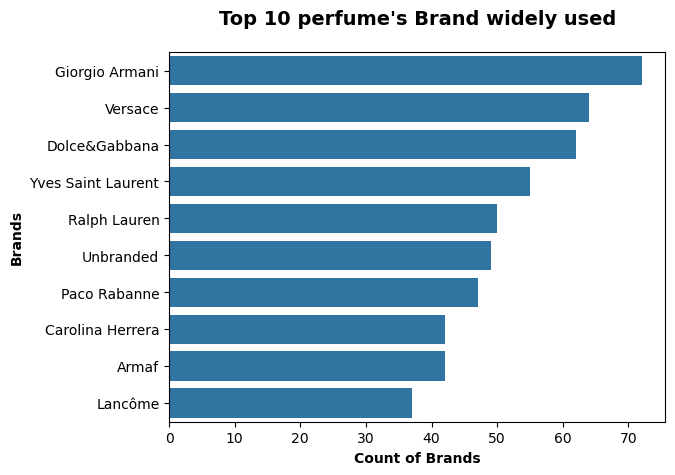

In [28]:
# Top 10 brands of perfume used
sns.countplot(data=df, y='brand', order=df['brand'].value_counts().head(10).index)
plt.title("Top 10 perfume's Brand widely used",  fontsize=14,
    fontweight='bold',
    loc='center',
    pad=20)
plt.xlabel("Count of Brands",fontweight = 'bold')
plt.ylabel("Brands", fontweight = 'bold')
plt.show()

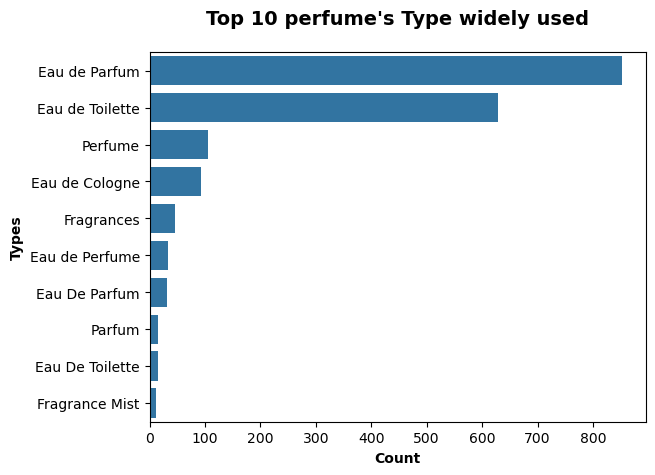

In [29]:
sns.countplot(data=df, y='type', order=df['type'].value_counts().head(10).index)
plt.title("Top 10 perfume's Type widely used",  fontsize=14,
    fontweight='bold',
    loc='center',
    pad=20)
plt.xlabel("Count",fontweight = 'bold')
plt.ylabel("Types", fontweight = 'bold')
plt.show()

Text(0.5, 0, 'Price ($)')

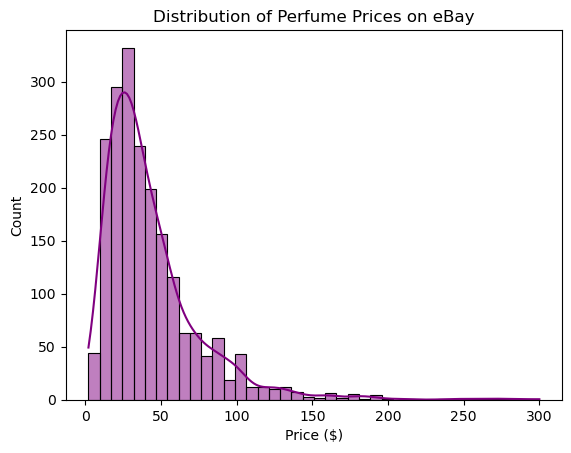

In [30]:
sns.histplot(data=df, x='price', kde=True, color='purple', bins=40)
plt.title('Distribution of Perfume Prices on eBay')
plt.xlabel('Price ($)')

Text(0, 0.5, 'Price ($)')

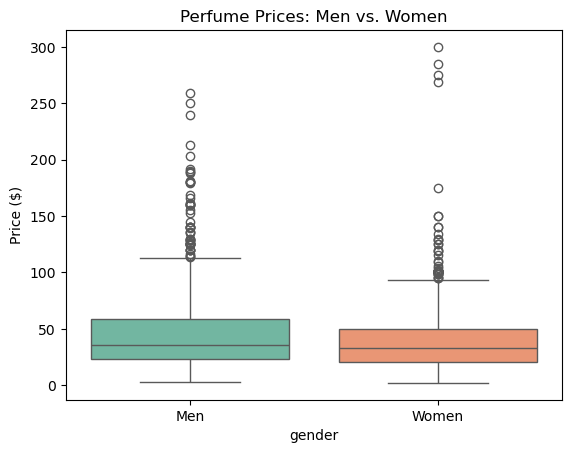

In [31]:
sns.boxplot(data=df, x='gender', y='price', palette='Set2', hue='gender', legend=False)
plt.title('Perfume Prices: Men vs. Women')
plt.ylabel('Price ($)')

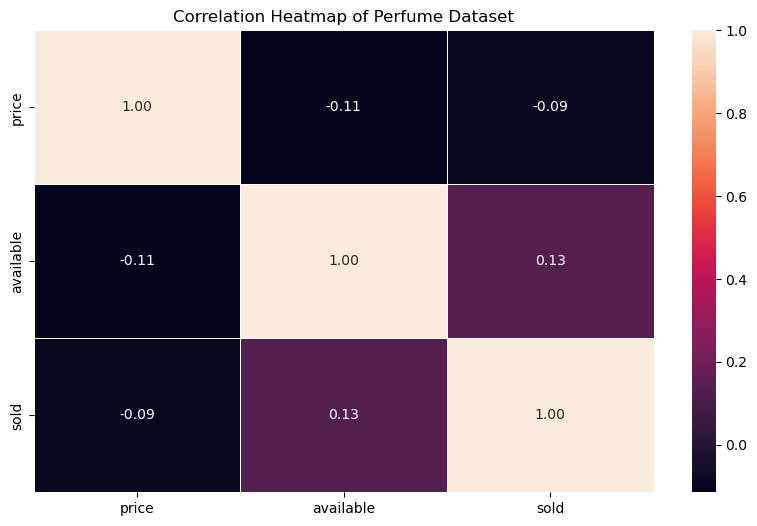

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Perfume Dataset")
plt.show()

The results show weak correlations between these variables, indicating minimal multicollinearity and suggesting that additional feature engineering may be needed to uncover deeper patterns.

# FEATURE ENGINEERING

In [38]:
# Extracting dates form the lastUpdated column
df['year'] = df['lastUpdated'].dt.year
df['month'] = df['lastUpdated'].dt.month
df['day'] = df['lastUpdated'].dt.day
df['weekday'] = df['lastUpdated'].dt.day_name()
df['hour'] = df['lastUpdated'].dt.hour

In [39]:
df[['lastUpdated','brand', 'year', 'month', 'day', 'weekday', 'hour']].head()

,lastUpdated,brand,year,month,day,weekday,hour
0,2024-05-24 10:03:04,Dior,2024.0,5.0,24.0,Friday,10.0
1,2024-05-23 23:07:49,AS SHOW,2024.0,5.0,23.0,Thursday,23.0
2,2024-05-22 21:55:43,Unbranded,2024.0,5.0,22.0,Wednesday,21.0
3,2024-05-24 03:30:43,Giorgio Armani,2024.0,5.0,24.0,Friday,3.0
4,2024-05-24 07:56:25,Lattafa,2024.0,5.0,24.0,Friday,7.0


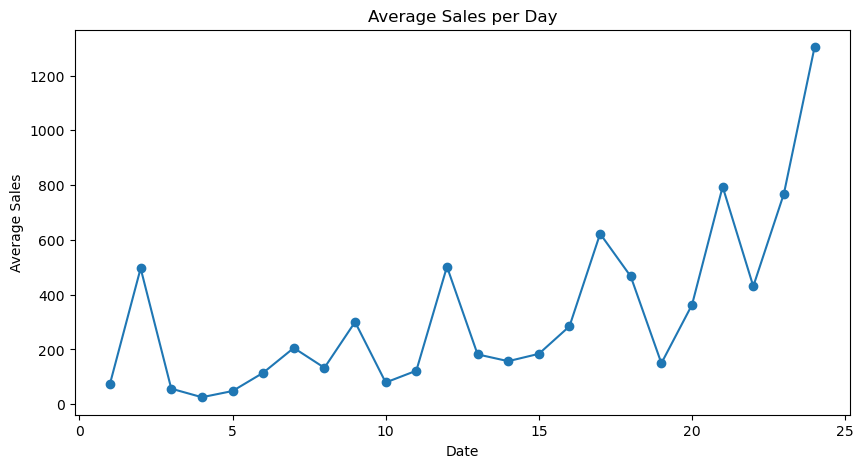

In [40]:
daily_sales = df.groupby(df['day'])['sold'].mean()
daily_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Average Sales per Day")
plt.ylabel("Average Sales")
plt.xlabel("Date")
plt.show()

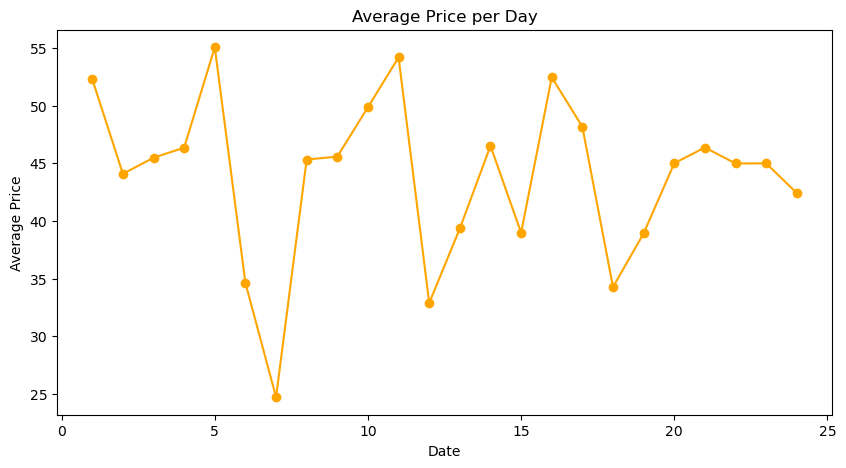

In [41]:
daily_price = df.groupby(df['day'])['price'].mean()
daily_price.plot(kind='line', marker='o', color='orange', figsize=(10,5))
plt.title("Average Price per Day")
plt.ylabel("Average Price")
plt.xlabel("Date")
plt.show()

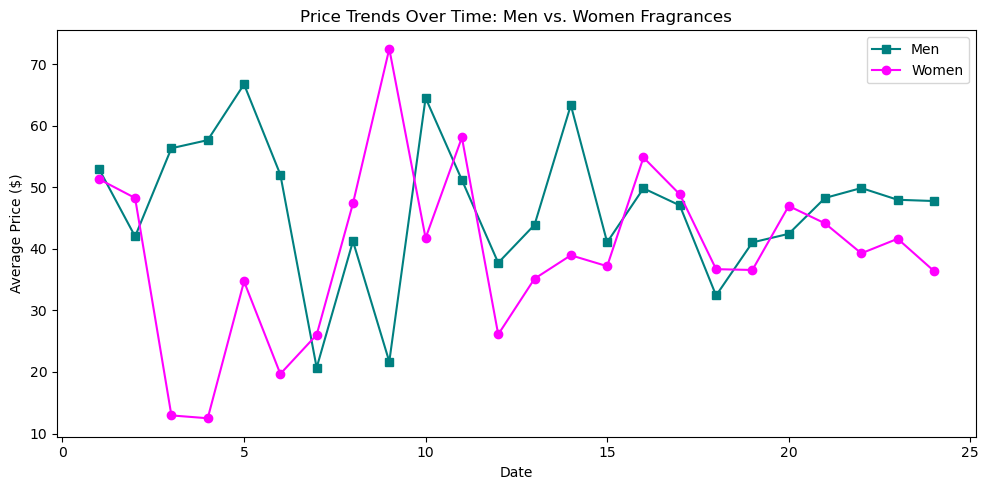

In [42]:
# Group by both Date and Gender
gender_trend = df.groupby([df['day'], 'gender'], observed=False)['price'].mean().unstack()

plt.figure(figsize=(10, 5))
plt.plot(gender_trend.index, gender_trend['Men'], marker='s', label='Men', color='teal')
plt.plot(gender_trend.index, gender_trend['Women'], marker='o', label='Women', color='magenta')
plt.title('Price Trends Over Time: Men vs. Women Fragrances')
plt.xlabel('Date')
plt.ylabel('Average Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
df['sales_to_price_ratio'] = df['sold'] / df["price"]
df[['brand', 'available' , 'price', 'sold', 'sales_to_price_ratio']].head()

,brand,available,price,sold,sales_to_price_ratio
0,Dior,10,84.99,116,1.364866
1,AS SHOW,8,109.99,48,0.436403
2,Unbranded,10,100.00,27,0.270000
3,Giorgio Armani,2,44.99,159,3.534119
4,Lattafa,10,16.91,156,9.225310


In [44]:
df["sales_to_price_ratio"].describe()

count    1999.000000
mean       27.253699
std       130.595226
min         0.000000
25%         0.333500
50%         1.494682
75%         9.475652
max      2839.398496
Name: sales_to_price_ratio, dtype: float64

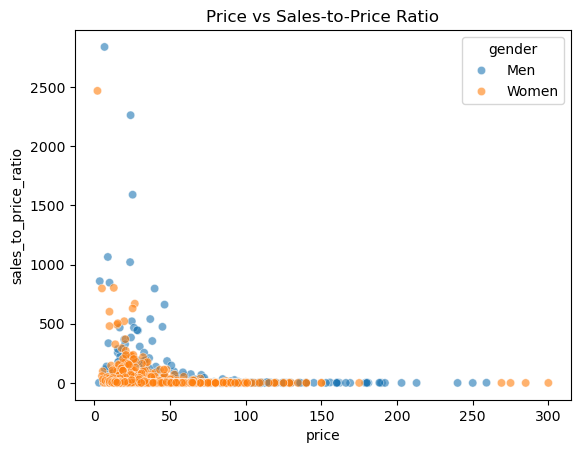

In [45]:
sns.scatterplot(x='price', y='sales_to_price_ratio', hue='gender', data=df, alpha=0.6)
plt.title("Price vs Sales-to-Price Ratio")
plt.show()

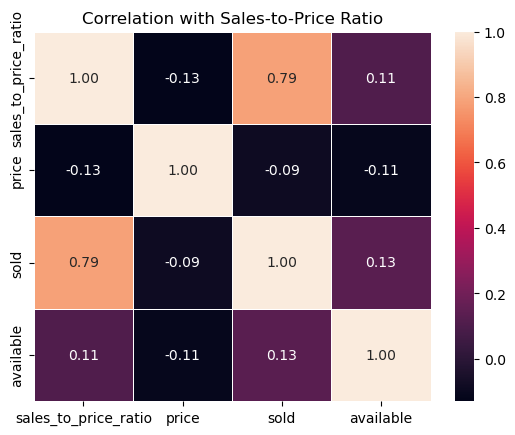

In [46]:
corr = df[['sales_to_price_ratio','price','sold','available']].corr()
sns.heatmap(corr, annot=True,fmt=".2f", linewidths=0.5)
plt.title("Correlation with Sales-to-Price Ratio")
plt.show()

**Aggregating Total Sales by Brand**

In [47]:
# Total sales per brand
brand_sales = df.groupby('brand')['sold'].sum().sort_values(ascending=False)

# Display the top 10 brands
top10_brands = brand_sales.head(10)
top10_brands

C:\Users\bishw\AppData\Local\Temp\ipykernel_9076\1116934714.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_sales = df.groupby('brand')['sold'].sum().sort_values(ascending=False)


brand
Calvin Klein       145672
Versace            136054
Davidoff            60289
Azzaro              38305
Burberry            38001
Liz Claiborne       29170
Dolce & Gabbana     28570
Armaf               27120
Kenneth Cole        24636
Paco Rabanne        23506
Name: sold, dtype: int64

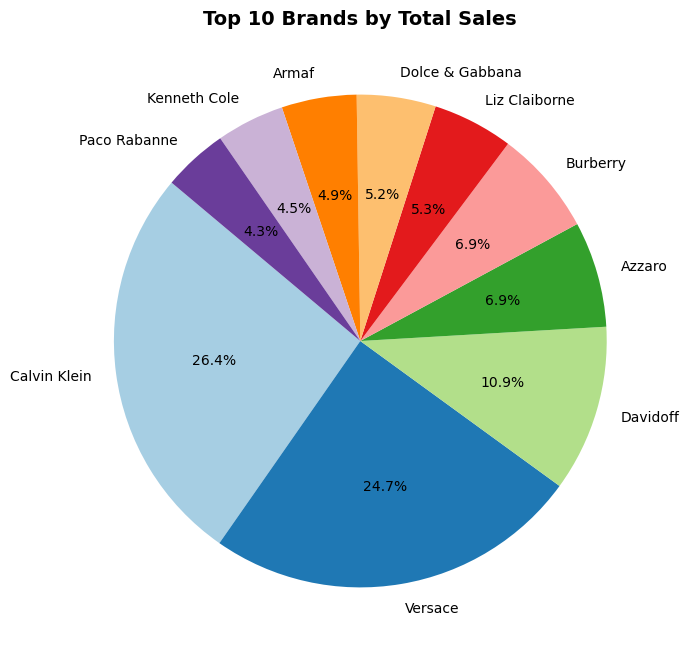

In [48]:
# Pie chart
plt.figure(figsize=(8,8))
plt.pie(
    top10_brands.values,
    labels=top10_brands.index,
    autopct='%1.1f%%',       # show percentages
    startangle=140,          # rotate for better layout
    colors=plt.cm.Paired.colors
)
plt.title("Top 10 Brands by Total Sales", fontsize=14, fontweight='bold')
plt.show()

The pie chart visually confirms that Calvin Klein and Versace are the top-selling perfume brands.

**ENCODING**

In [54]:
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['gender']])

In [66]:
# Convert to DataFrame
encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(['gender']), index=df.index)
# Merge with original
df_encoded = pd.concat([df.drop('gender', axis=1), encoded_df], axis=1)

In [67]:
df_encoded[['brand', 'gender_Men', 'gender_Women']].head()

,brand,gender_Men,gender_Women
0,Dior,1.0,0.0
1,AS SHOW,1.0,0.0
2,Unbranded,1.0,0.0
3,Giorgio Armani,1.0,0.0
4,Lattafa,1.0,0.0


**Categorizing Perfumes by Price Range: Budget to Luxury**

In [68]:
df['price'].describe ()

count    1999.000000
mean       43.184682
std        32.627610
min         1.990000
25%        21.965000
50%        34.000000
75%        53.990000
max       299.990000
Name: price, dtype: float64

In [69]:
df_encoded['price_range'] = pd.cut(df_encoded['price'], bins=4, labels=['Low', 'Medium', 'High', 'Luxury'])

In [70]:
df_encoded[['brand', 'type', 'gender_Men', 'gender_Women', 'price', 'price_range']]

,brand,type,gender_Men,gender_Women,price,price_range
0,Dior,Eau de Parfum,1.0,0.0,84.99,Medium
1,AS SHOW,Eau de Parfum,1.0,0.0,109.99,Medium
2,Unbranded,Eau de Toilette,1.0,0.0,100.00,Medium
3,Giorgio Armani,Eau de Toilette,1.0,0.0,44.99,Low
4,Lattafa,Fragrances,1.0,0.0,16.91,Low
...,...,...,...,...,...,...
1995,Avon,Eau de Parfum,0.0,1.0,13.89,Low
1996,Mancera,Eau de Parfum,0.0,1.0,57.85,Low
1997,Unbranded,1,0.0,1.0,30.96,Low
1998,Juliette Has A Gun,Eau de Perfume,0.0,1.0,53.99,Low


<Axes: xlabel='price_range', ylabel='count'>

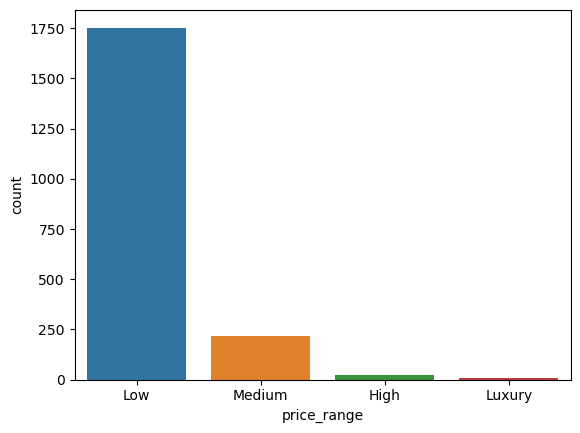

In [95]:
# visualization to look which price_range is highest
sns.countplot(x='price_range', data=df_encoded, hue='price_range')

This chart indicates that most perfumes are budget or affordable, while medium, high, and luxury categories make up only a small fraction of the data.